# ECMWF Open Data: Catalog & Access Mechanisms

---

## Learning objectives

By the end of this notebook you will be able to:

1. Describe what is in the ECMWF Free & Open Data catalogue and how it is organised
2. Understand the **IFS 50r1** naming changes (IFS ENS control deprecated; deterministic is `oper/fc`)
3. Browse the live index at `data.ecmwf.int` to discover available runs and steps
4. Download a GRIB2 file directly from the live index (three more download methods in Notebook 02)
5. Inspect file contents with **earthkit.data** and plot a field by `shortName`

---

## Introduction

ECMWF's **Free and Open Data** is a curated subset of operational forecasts published under **CC BY 4.0**: no credentials required.  
It is available at `data.ecmwf.int` (FTP/HTTPS) and mirrored on AWS S3, Azure, and Google Cloud.

### What's in the catalogue (IFS Cycle 50r1, from 12 May 2026)

| Product | Path | File suffix | Freq | Steps |
|---|---|---|---|---|
| IFS deterministic (formerly HRES) | `ifs/0p25/oper/` | `oper-fc` | 4x/day | 0-360 h |
| IFS ENS perturbed | `ifs/0p25/enfo/` | `enfo-ef` | 4x/day | 0-360 h |
| IFS ENS probabilities | `ifs/0p25/enfo/` | `enfo-ep` | 00z/12z | `240h`/`360h` container files |
| AIFS deterministic | `aifs-single/0p25/oper/` | `oper-fc` | 4x/day | 0-360 h |
| AIFS ENS control | `aifs-ens/0p25/enfo/` | `enfo-cf` | 4x/day | 0-360 h |
| AIFS ENS perturbed | `aifs-ens/0p25/enfo/` | `enfo-pf` | 4x/day | 0-360 h |
| AIFS Waves deterministic | `aifs-single/0p25/wave/` | `wave-fc` | 4x/day | 0-360 h |
| AIFS Waves ENS | `aifs-ens/0p25/waef/` | `waef-cf`/`waef-pf` | 4x/day | 0-360 h |
| IFS Waves deterministic | `ifs/0p25/wave/` | `wave-fc` | 4x/day | 0-360 h |
| IFS Waves ENS | `ifs/0p25/waef/` | `waef-ef` | 4x/day | 0-360 h |
| IFS Waves ENS probabilities | `ifs/0p25/waef/` | `waef-ep` | 00z/12z | `240h`/`360h` container files |
| TC tracks | BUFR | - | 4x/day | real-time |

> **IFS Cycle 50r1 changes (12 May 2026):**
> - `stream=scda` and `stream=scwv` deprecated: 06z/18z data now under `oper` and `wave`
> - IFS ENS control (`enfo/cf`) deprecated: the IFS deterministic is now accessed via `stream=oper, type=fc`
> - IFS ENS perturbed file suffix changed: `enfo-pf` to `enfo-ef`
> - Wave ENS file suffix changed: `waef-cf/pf` to `waef-ef`
> - AIFS-ENS unchanged: still `enfo-cf` / `enfo-pf`
> - **Existing workflows using `stream=oper, type=fc` for IFS deterministic: no change needed**

### What's coming

- **Native 9 km resolution** in the free open subset: later in 2026 (currently 0.25°)
- **Full GRIB2** output (IFS 50r2, Q3 2026): resolves the current GRIB1/GRIB2 mix

### Licence

All open data is published under [Creative Commons Attribution 4.0 (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/).  
Attribution: *"ECMWF"* or *"Generated using Copernicus Climate Change Service information YYYY"*.

---

**Prerequisites:** Python 3.10+, `ecmwf-opendata`, `earthkit-data`, `earthkit-plots`, `requests`  
**Run time:** ~5 minutes (downloads ~5 MB)  
**Data:** live from `data.ecmwf.int`: no credentials needed

> **Status note (July 2026):** Written against the ECMWF Open Data catalogue as of mid-2026 (IFS cycle 50r1, 0.25 degree grid). An update to the Free and Open Data offering, including a move to 0.1 degree resolution, is expected later in 2026: file naming and catalogue examples here may need revisiting after that release.


## ECMWF Open Data: quick facts & naming (50r1)

ECMWF Open Data uses a **0.25° global grid** in **GRIB2**. Data is regridded from native model resolution.

### Key naming since IFS Cycle 50r1 (12 May 2026)

- **IFS deterministic** (`stream=oper, type=fc`) - the main forecast product, replaces what was called HRES.
  If you have existing code using `stream=oper, type=fc`: no change needed.
- **IFS ENS perturbed** (`stream=enfo, type=pf`) - 50 perturbed members. File suffix changed from `enfo-pf` to `enfo-ef`.
- **IFS ENS control** (`stream=enfo, type=cf`) - **deprecated in 50r1**. Use `oper/fc` instead.
- **AIFS single** (`aifs-single`, `stream=oper, type=fc`) - AI model, 4x/day. Also produces wave output (`stream=wave`).
- **AIFS ENS** (`aifs-ens`, `stream=enfo, type=cf/pf`) - AI ensemble, unchanged. Wave ensemble under `stream=waef` (`waef-cf/pf`).
- **Waves deterministic** (`stream=wave, type=fc`) - unchanged.
- **Waves ENS** (`stream=waef`) - file suffix changed from `waef-cf/pf` to `waef-ef`.
- **scda/scwv deprecated** - 06z/18z high-frequency data now under `oper` and `wave`.
- **Probability products** (`type=ep`, suffixes `enfo-ep`/`waef-ep`) - pre-computed ensemble probabilities (e.g. precipitation and wind gust threshold exceedance), 00z and 12z runs only. Filenames carry `240h` (containing steps 0-240h) or `360h` (steps 246-360h).

### Access endpoints

| Method | URL / command | Notes |
|---|---|---|
| Python client | `pip install ecmwf-opendata` | Recommended |
| FTP/HTTPS | `data.ecmwf.int/forecasts/` | Browse live index |
| AWS S3 | `s3://ecmwf-forecasts/` (public) | No credentials |
| Azure STAC | Planetary Computer | See Notebook 04 |
| Google Cloud | `gs://ecmwf-open-data` (public) | See Notebook 04 |


## 1) Setup & imports

We start out by importing the required libraries and support functions in _utils. We also setup a **single cache** so every notebook stores data under `data/` at the repo root.

In [1]:
# Imports and shared setup
from datetime import datetime, timedelta, timezone
from pathlib import Path
import re, requests

import earthkit.data as ekd
from earthkit.data import from_source

from _utils import get_data_dir, quick_plot

DATA_DIR = Path(get_data_dir())   # one cache for all notebooks (repo-root /data)
print("Data cache:", DATA_DIR)
print("earthkit-data:", ekd.__version__)

# Pick a safe recent run: new runs publish with a delay, so give a buffer
now = datetime.now(timezone.utc)
if   now.hour >= 22:  run_date = now;                     run_hour = 12  # today 12z fully online
elif now.hour >= 10:  run_date = now;                     run_hour = 0   # today 00z
else:                 run_date = now - timedelta(days=1); run_hour = 12  # yesterday 12z

fc_date = run_date.strftime("%Y%m%d")
fc_time = f"{run_hour:02d}"
print(f"Safe recent run: {fc_date} {fc_time}z")


Data cache: /Users/valtze/ecmwf-open-data-guide/data
earthkit-data: 0.19.4
Safe recent run: 20260708 00z


## 2) Browse the live index

Here we mirror the public layout and discover available **steps** for following selection. We basically map out the data available in the FTP resource.

In [2]:
BASE = "https://data.ecmwf.int/forecasts"

RUNS_UTC = ["00", "06", "12", "18"]

# IFS Cycle 50r1 changes (from 12 May 2026)
# - stream=scda/scwv deprecated: 06z/18z now under oper/wave
# - IFS ENS control (enfo/cf) deprecated: deterministic is now oper/fc
# - IFS ENS perturbed suffix changed: enfo-pf to enfo-ef
# - Wave ENS suffix changed: waef-cf/pf to waef-ef
# - AIFS-ENS unchanged: still enfo-cf / enfo-pf

# The catalogue, keyed by the REAL portal tokens: model -> stream -> file suffixes.
# URL layout: {BASE}/{date}/{run}z/{model}/0p25/{stream}/{date}{run}0000-{step}h-{suffix}.grib2
# The stream is the first part of the suffix (enfo-ef -> stream enfo).
# ep = probability container files (00z/12z, 240h/360h only); tf = TC tracks (BUFR): both
# listed in the naming section above, not downloadable with this notebook.
# Verified against the live portal directory structure, July 2026.
CATALOGUE = {
    "ifs": {                                  # physics-based model
        "oper": ["oper-fc"],                  # deterministic (formerly HRES)
        "enfo": ["enfo-ef", "enfo-ep"],       # ensemble (ef was pf pre-50r1)
        "wave": ["wave-fc"],                  # wave deterministic
        "waef": ["waef-ef", "waef-ep"],       # wave ensemble (ef was cf/pf pre-50r1)
    },
    "aifs-single": {                          # AI model, deterministic
        "oper": ["oper-fc"],
        "wave": ["wave-fc"],
    },
    "aifs-ens": {                             # AI ensemble (pre-50r1 suffix style retained)
        "enfo": ["enfo-cf", "enfo-pf"],
        "waef": ["waef-cf", "waef-pf"],
    },
}

def dir_url_for(date_str, run_str, model, stream):
    run_z = f"{run_str}z" if not str(run_str).endswith("z") else str(run_str)
    return "/".join([BASE, str(date_str), run_z, model, "0p25", stream]) + "/"

def available_steps(date_str, run_str, model, suffix):
    """List forecast steps that exist on the portal for this model + suffix.
    Returns (dir_url, steps, error) - error is None on success."""
    import requests, re, time
    stream = suffix.split("-")[0]
    url = dir_url_for(date_str, run_str, model, stream)
    try:
        time.sleep(0.5)   # politeness: the portal caps simultaneous connections
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        pattern = re.compile(r'\d{12}-(\d+)h-' + re.escape(suffix) + r'\.grib2')
        steps = sorted(set(int(x) for x in pattern.findall(r.text)))
        return url, steps, None
    except Exception as e:
        return url, [], repr(e)


## 3) Select and download a file

The sweep below checks every model/suffix combination against the live index, printing
what exists right now. It doubles as a health check of the catalogue map above.

Then, exactly as with `shortName` plotting later: **type values from the table** into the
selection variables (`MODEL`, `SUFFIX`, plus date/run/step) and rerun the cell to download.
Files are cached under `./data/` with their exact remote names.

- Where a stream lists two suffixes, note the sizes: `-pf` ensemble files run to several GB;
  control/deterministic files are the safe choice here.
- Full `oper-fc` files are ~130 MB; wave files ~10 MB.


In [3]:
# --- Availability sweep: check every model/suffix combination on the live portal ---
print(f"Availability sweep: {fc_date} {fc_time}z")
print(f"{'MODEL':<13} {'SUFFIX':<9} {'steps':>6}   first/last")
print("-" * 46)
for _model, _streams in CATALOGUE.items():
    for _stream, _suffixes in _streams.items():
        for _suf in _suffixes:
            if _suf.endswith("-ep"):
                print(f"{_model:<13} {_suf:<9} {'-':>6}   240h/360h container files (see naming section)")
                continue
            _url, _steps, _err = available_steps(fc_date, fc_time, _model, _suf)
            if _err:
                print(f"{_model:<13} {_suf:<9} {'ERR':>6}   {_err[:50]}")
            elif _steps:
                print(f"{_model:<13} {_suf:<9} {len(_steps):>6}   {_steps[0]}h / {_steps[-1]}h")
            else:
                print(f"{_model:<13} {_suf:<9} {0:>6}   none listed")


Availability sweep: 20260708 00z
MODEL         SUFFIX     steps   first/last
----------------------------------------------
ifs           oper-fc       85   0h / 360h
ifs           enfo-ef       85   0h / 360h
ifs           enfo-ep        -   240h/360h container files (see naming section)
ifs           wave-fc       85   0h / 360h
ifs           waef-ef       85   0h / 360h
ifs           waef-ep        -   240h/360h container files (see naming section)
aifs-single   oper-fc       61   0h / 360h
aifs-single   wave-fc       61   0h / 360h
aifs-ens      enfo-cf       61   0h / 360h
aifs-ens      enfo-pf       61   0h / 360h
aifs-ens      waef-cf       61   0h / 360h
aifs-ens      waef-pf       61   0h / 360h


If no steps appear for your selection: try another run (`00` instead of `12`) or the
previous UTC day: the rolling archive keeps roughly the last 2-3 days.


In [4]:
# --- Select (type values from the sweep table) and download ---
MODEL   = "aifs-single"          # ifs | aifs-single | aifs-ens
SUFFIX  = "oper-fc"      # a suffix listed for that model in the sweep table
DATE    = fc_date        # YYYYMMDD, within the ~2-3 day rolling window
RUN     = fc_time        # 00 / 06 / 12 / 18
STEP_H  = 24              # a step listed for this combination

def build_filename(date_str, run_str, step_h, suffix):
    """Example: 20260707000000-6h-oper-fc.grib2"""
    return f"{date_str}{int(str(run_str)):02d}0000-{int(str(step_h))}h-{suffix}.grib2"

_stream = SUFFIX.split("-")[0]
if MODEL not in CATALOGUE or _stream not in CATALOGUE[MODEL] or SUFFIX not in CATALOGUE[MODEL][_stream]:
    raise ValueError(f"{SUFFIX!r} is not a valid suffix for model {MODEL!r}: see the sweep table")
dir_url, steps, _err = available_steps(DATE, RUN, MODEL, SUFFIX)
if _err:
    raise RuntimeError(f"Portal listing failed: {_err}")
if STEP_H not in steps:
    raise ValueError(f"Step {STEP_H} not available for {MODEL}/{SUFFIX}; choose from {steps[:8]}...")

fname  = build_filename(DATE, RUN, STEP_H, SUFFIX)
target = DATA_DIR / fname

if target.exists():
    print(f"Using cached: {target.name} ({target.stat().st_size/1e6:.1f} MB)")
else:
    file_url = dir_url + fname
    print(f"Downloading: {file_url}")
    with requests.get(file_url, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(target, "wb") as f:
            for chunk in r.iter_content(1024 * 1024):
                if chunk:
                    f.write(chunk)
    print(f"Saved: {target} ({target.stat().st_size/1e6:.1f} MB)")

_cached = sorted(DATA_DIR.glob("*.grib2"))
if _cached:
    print("In cache:", ", ".join(p.name for p in _cached[-6:]))

# Names kept for the Explore/Plot cells and Notebook 02 (unchanged contract)
date_str, run_str, step_h, product_suffix = DATE, RUN, STEP_H, SUFFIX
class _PickerShim:
    def __init__(self, path): self.last_path = Path(path)
    def get_selected_local_path(self): return self.last_path
picker = _PickerShim(target)


Downloading: https://data.ecmwf.int/forecasts/20260708/00z/aifs-single/0p25/oper/20260708000000-24h-oper-fc.grib2
Saved: /Users/valtze/ecmwf-open-data-guide/data/20260708000000-24h-oper-fc.grib2 (83.9 MB)
In cache: hres_msl_2t_10uv.grib2, hres_pl_truv_step0.grib2, hres_ts_2t.grib2, ifs_simple.grib2, wave_deterministic_swh_mwp_mwd.grib2, wave_ensemble_pf_swh_mwp_mwd.grib2


## 4) Explore

Once the data is saved we can open the downloaded GRIB with Earthkit and inspect it in a concise inventory.  
We will use the `shortName` column (e.g., `2t`, `msl`, `tp`) for plotting next.


In [5]:
# Explore: prefer the widget's picker; fall back to `target` saved by the Download button
from pathlib import Path
from earthkit.data import from_source

p = None

# 1) Try the widget
if 'picker' in globals():
    try:
        p = getattr(picker, 'last_path', None) or (
            picker.get_selected_local_path() if hasattr(picker, 'get_selected_local_path') else None
        )
    except Exception:
        p = None

# 2) Fall back to the explicit path set by the download step
if (p is None or not Path(p).exists()) and globals().get('target'):
    p = Path(globals()['target'])

# 3) Friendly error if nothing was downloaded
if not p or not Path(p).exists():
    raise FileNotFoundError("No file downloaded yet. Use the Download button first.")

ds = from_source("file", str(p))
ds.describe()


,,level,date,time,step,number,paramId,class,stream,type,experimentVersionNumber
shortName,typeOfLevel,,,,,,,,,,
100u,heightAboveGround,100,20260708,0,24,None,228246,ai,oper,fc,0001
100v,heightAboveGround,100,20260708,0,24,None,228247,ai,oper,fc,0001
10u,heightAboveGround,10,20260708,0,24,None,165,ai,oper,fc,0001
10v,heightAboveGround,10,20260708,0,24,None,166,ai,oper,fc,0001
2d,heightAboveGround,2,20260708,0,24,None,168,ai,oper,fc,0001
2t,heightAboveGround,2,20260708,0,24,None,167,ai,oper,fc,0001
cp,surface,0,20260708,0,24,None,228143,ai,oper,fc,0001
fscov,surface,0,20260708,0,24,None,260289,ai,oper,fc,0001
gh,isobaricInhPa,"100,200,...",20260708,0,24,None,156,ai,oper,fc,0001


## 5) Plot by `shortName`

Type one of the `shortName` values from the Explore table above (e.g. `2t`, `msl`, `tp`)
into the widget and press Plot. If it fails, check the spelling against the table.


Output()

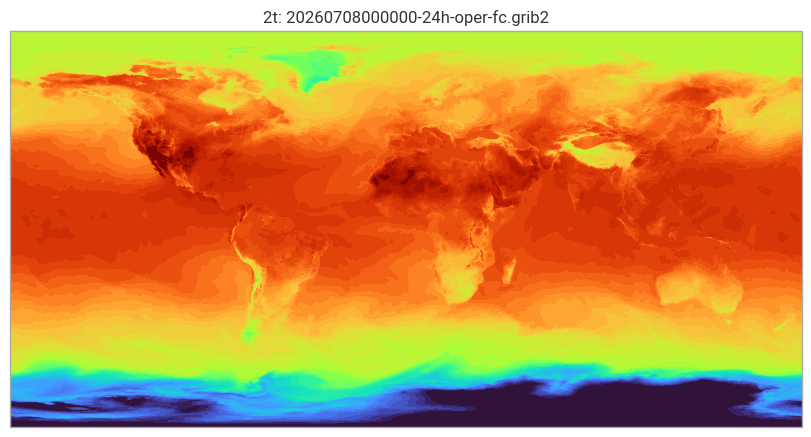

In [6]:
import ipywidgets as widgets
from IPython.display import display

param = widgets.Text(description="shortName", placeholder="e.g. 2t, msl, tp")
plot_btn = widgets.Button(description="Plot", button_style="primary")
outp = widgets.Output()

def _plot(_):
    with outp:
        outp.clear_output()
        name = (param.value or "").strip().lower()
        if not name:
            print("Type a shortName from the Explore table above (e.g. 2t, msl, tp).")
            return
        for i, f in enumerate(ds):
            if (f.metadata().get("shortName") or "").lower() == name:
                try:
                    quick_plot(ds[i], title=f"{name}: {Path(target).name}")
                except Exception as e:
                    print("Plot failed for this field:", repr(e))
                return
        print(f"shortName {param.value!r} not found. Check the Explore table and try again.")

plot_btn.on_click(_plot)
display(widgets.HBox([param, plot_btn]), outp)


> **See also:** [Notebook 02](02_opendata_download_methods.ipynb)
Download methods: curl, requests, HTTP Range, ecmwf-opendata client, earthkit direct fetch


## Take-home messages

You have just:
- Understood the **ECMWF Open Data catalogue** structure and the **50r1 naming changes**
- Browsed the **live index** at `data.ecmwf.int` and picked a real run/step
- Downloaded a GRIB2 file directly from the live index (three more methods in Notebook 02)
- Inspected contents with `earthkit.data` and plotted a field by `shortName`

---

### Next steps

- **Notebook 03: Open Data: retrieval and plotting with earthkit**  
  Automate safe run/step selection; fetch IFS, AIFS, and ENS; compare models; Africa domain; vertical profile.

- **Notebook 04: Cloud endpoints (AWS S3, Azure, GCS)**  
  Fetch the same data without the `ecmwf-opendata` client using HTTP Range requests directly.

- **Notebook 05: Copernicus ERA5 via CDS**  
  Access climate reanalysis (1940-present) using `cdsapi` and `earthkit.data`.

### Support & feedback

- Questions and bug reports: [support.ecmwf.int](https://support.ecmwf.int)
- Open Data documentation: [confluence.ecmwf.int/display/DAC/ECMWF+open+data](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data)
- This notebook: [github.com/valtzen/ecmwf-open-data-guide](https://github.com/valtzen/ecmwf-open-data-guide)
